In [1]:
import os
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import scvi

import session_info

sys.path.append('/nfs/team205/is10/scripts/')
from single_cell_utils import *

In [2]:
work_dir = '/lustre/scratch126/cellgen/team205/is10/side_projects/thymus_flux/foetal_T_cells/'
os.makedirs(work_dir, exist_ok=True)

In [3]:
## Filtered and annotated object
adata = sc.read_h5ad('/nfs/team205/is10/projects/thytrans/data/references/HTSA/adata_full_rev_v2_ILC.h5ad')

In [4]:
## Subset for foetal single-cell samples
adata = adata[adata.obs['age_group'] == 'fetal'].copy()

In [5]:
adata.obs['enrichment'].value_counts()

enrichment
45N      81278
45P      38154
TOT      24760
EPCAM     3580
CD137     3558
Name: count, dtype: int64

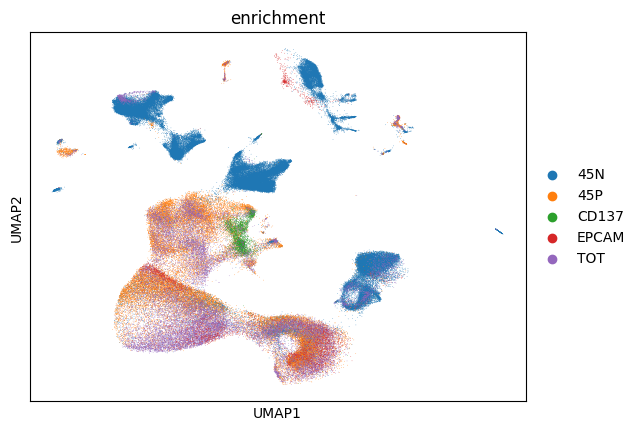

In [6]:
sc.pl.umap(adata, color='enrichment')

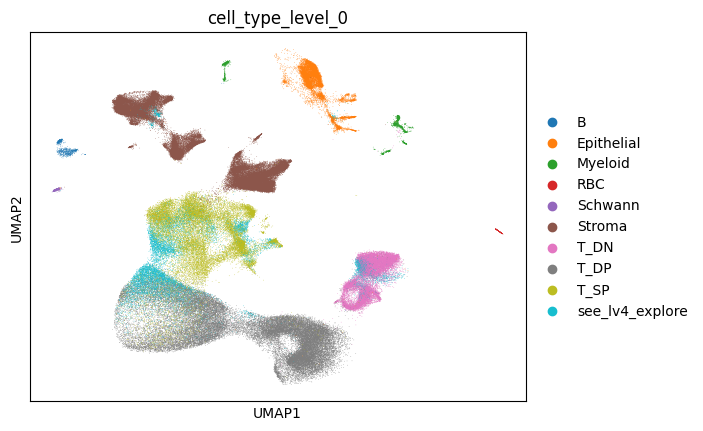

In [7]:
sc.pl.umap(adata, color='cell_type_level_0')

In [8]:
## Focusing on T cells and on TOT/45P enrichment (CD137 is enriching for specific T cell subsets which will bias our results)

In [9]:
adata = adata[(adata.obs['enrichment'].isin(['45P', 'TOT'])) & (adata.obs['cell_type_level_0'].str.startswith('T_'))]

In [10]:
adata

View of AnnData object with n_obs × n_vars = 50816 × 36601
    obs: 'n_genes', 'sample_barcode', 'batch', 'chemistry_simple', 'age_group', 'age_numeric', 'sampleID_TCRab', 'path_TCRab', 'path_cellbender_gex', 'study', 'study_group', 'sample', 'enrichment', 'donor', 'cite', 'sex', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'barcode_sequence', 'backup_barcode', 'louvian_05', 'leiden_05', 'leiden_1', 'leiden_2', 'park_2020_cell_type', 'panfetal_2022_cell_type', 'cell_type_level_4', 'cell_type_level_3', 'cell_type_level_2', 'cell_type_level_1', 'cell_type_level_0', 'pseudotime_nhood_vdj', 'prob_CD8+T_nhood_vdj', 'prob_CD4+T_nhood_vdj', 'leiden_3', 'leiden_4', 'unannotated', 'pred_cell_type_level_4', 'pred_cell_type_level_4_uncertainties', 'undefined', 'RNA.weight', 'ADTdsb.weight', 'low_ADT', 'spt_CD4', 'spt_CD8', 'anno_C

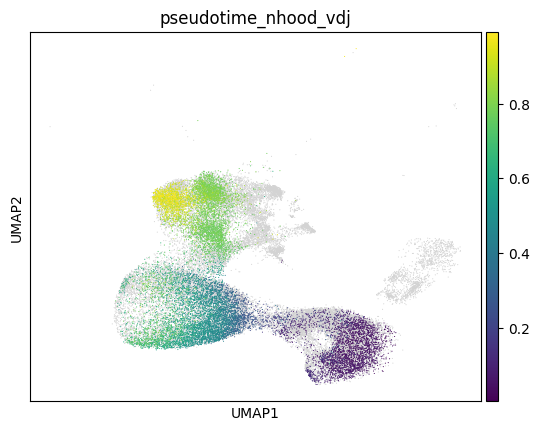

In [11]:
sc.pl.umap(adata, color='pseudotime_nhood_vdj')

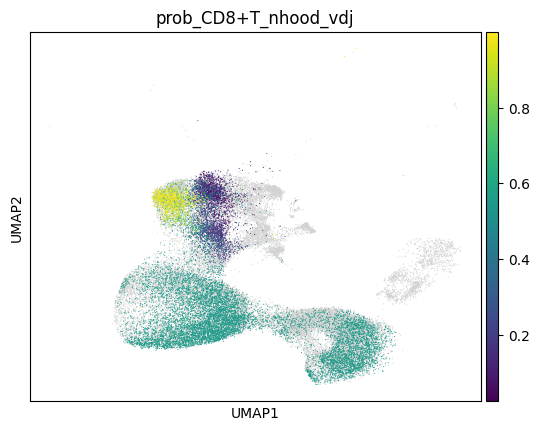

In [12]:
sc.pl.umap(adata, color='prob_CD8+T_nhood_vdj')

In [13]:
## Keep raw counts as backup
adata.layers['counts'] = adata.X.copy()

/tmp/ipykernel_3488045/1660722512.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy()


In [14]:
## Export
adata.write_h5ad(work_dir + 'adata_foetal_T_cells.h5ad')

In [15]:
adata.obs['donor'].value_counts()

donor
F67    11230
F64     9954
F29     8072
F30     6278
F41     3956
F45     3463
F38     2944
F21     2878
F23     2041
Name: count, dtype: int64

In [16]:
## HVG selection
adata_r = adata.copy()

## Exclude CC genes, MT-genes and CITE-seq entries, as well as VDJ genes
cc_genes = []
with open('/nfs/team205/is10/resources/human_cell_cycle_genes.txt', 'r') as f:
    for line in f:
        cc_genes.append(line.rstrip())

adata_r = remove_genes(adata_r, genes2remove=cc_genes, prefix=['MT-', 'cite_'], regex='^TR[AB][VDJ]|^IG[HKL][VDJC]')

/nfs/team205/is10/miniconda/envs/scvi_24/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:163: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


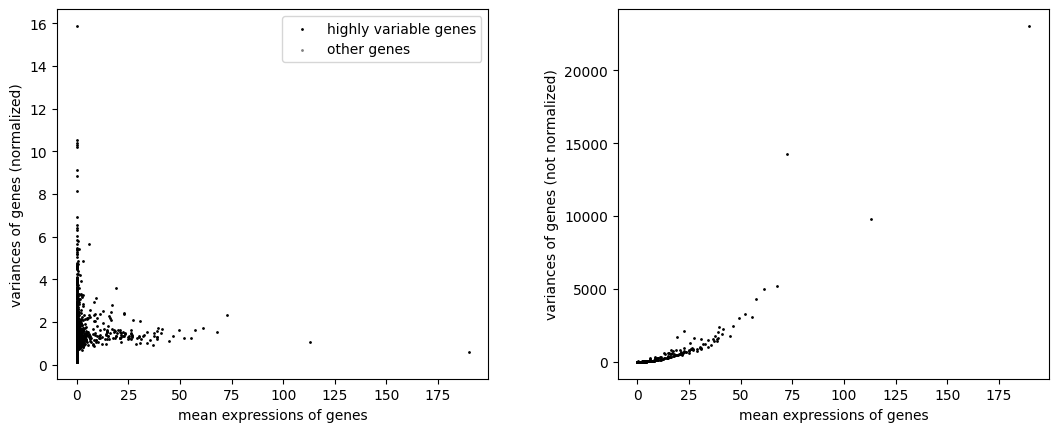

In [17]:
## Highly variable genes (per sample, then taking those appearing as HVGs in the most samples)
sc.pp.highly_variable_genes(
    adata_r,
    n_top_genes=5000,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="donor",
    span=1,
)

sc.pl.highly_variable_genes(adata_r)

In [19]:
hvgs = adata_r.var_names
pd.Series(hvgs).to_csv((work_dir + '5K_HVGs.txt'), index=None, header=None)

In [20]:
## Temporarily save for scVI integration
adata_r.write_h5ad(work_dir + 'adata_input_HVGs.h5ad')

In [3]:
## scVI integration
adata_r = sc.read((work_dir + 'adata_input_HVGs.h5ad'))

In [4]:
## Set up scVI
scvi.model.SCVI.setup_anndata(adata_r,
                              layer="counts",
                              categorical_covariate_keys=[
                                                          'donor',
                                                          'chemistry_simple'
                                                          ]
                             )

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
vae = scvi.model.SCVI(adata_r,
                      n_layers=3,
                      n_hidden=128,
                      n_latent=50,
                      gene_likelihood="zinb",
                      dispersion='gene')
vae.view_anndata_setup()

Anndata setup with scvi-tools version 1.1.2.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': None,
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': ['donor', 'chemistry_simple'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 50816 │
│ n_extra_categorical_covs │   2   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 5000  │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │           adata.layers['counts']           │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

               extra_categorical_covs State Registry                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃        Source Location        ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['chemistry_simple'] │    3GEX    │          0          │
│                               │    5GEX    │          1          │
│                               │            │                     │
│      adata.obs['donor']       │    F21     │          0          │
│                               │    F23     │          1          │
│                               │    F29     │          2          │
│                               │    F30     │          3          │
│                               │    F38     │          4          │
│                               │    F41     │          5          │
│                               │    F45     │          6          │
│                               │    F64     │          7          │
│                               │    F67     │          8          │
│                               │            │                     │
└───────────────────────────────┴────────────┴─────────────────────┘

In [6]:
## Train 
vae.train(max_epochs=300,batch_size=500)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 300/300: 100%|█| 300/300 [03:28<00:00,  1.44it/s, v_num=1, 

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|█| 300/300 [03:28<00:00,  1.44it/s, v_num=1, 


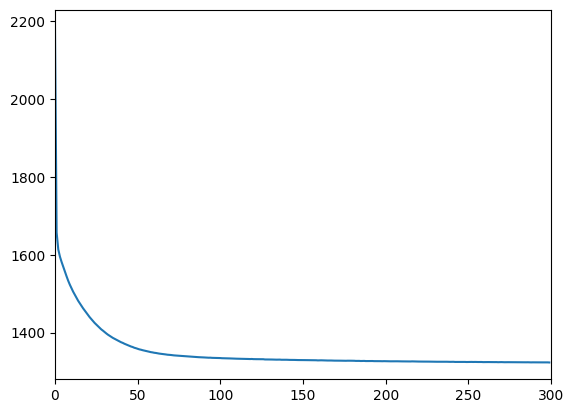

In [7]:
## Plot training history
plt.plot(vae.history['elbo_train'][:]);
plt.xlim(0, len(vae.history['elbo_train']));

In [8]:
## Save model
vae.save((work_dir + 'scVI_model'))

In [9]:
## And save latent dimensions
np.save((work_dir + "scVI_model_X.npy"), vae.get_latent_representation())

In [10]:
## Load full dataset
adata = sc.read_h5ad((work_dir + 'adata_foetal_T_cells.h5ad'))

In [11]:
## Add scVI latent space to original object
adata.obsm["X_scVI"] = np.load((work_dir+ "scVI_model_X.npy"))

In [12]:
## Find neighbors, run Leiden clustering and UMAP
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata, min_dist = 0.1, spread = 1)

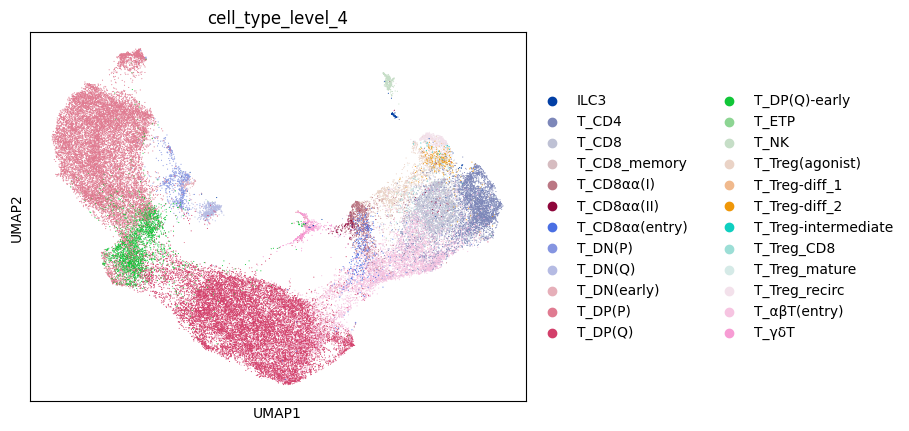

In [13]:
sc.pl.umap(adata, color=['cell_type_level_4'])

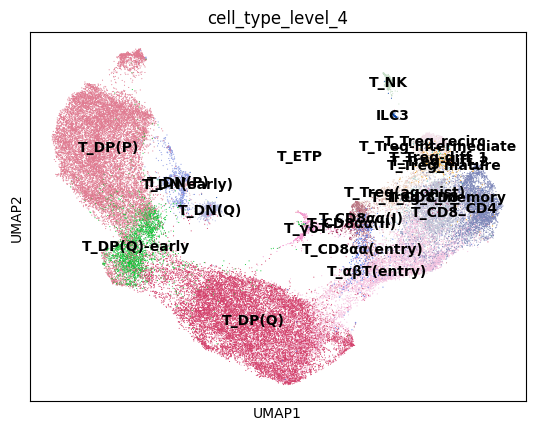

In [14]:
sc.pl.umap(adata, color=['cell_type_level_4'], legend_loc='on data')

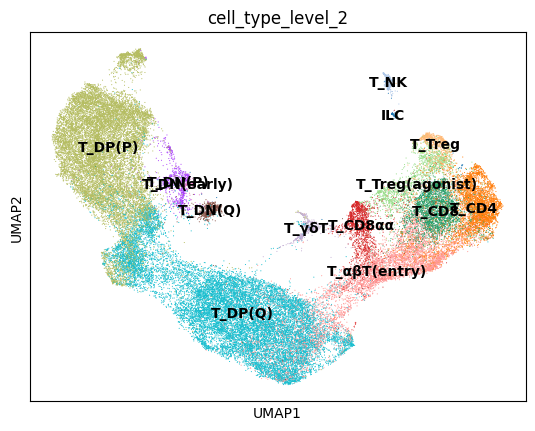

In [15]:
sc.pl.umap(adata, color=['cell_type_level_2'], legend_loc='on data')

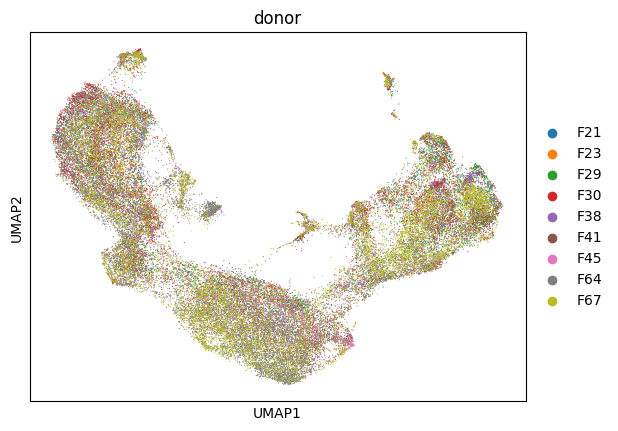

In [16]:
sc.pl.umap(adata, color=['donor'])

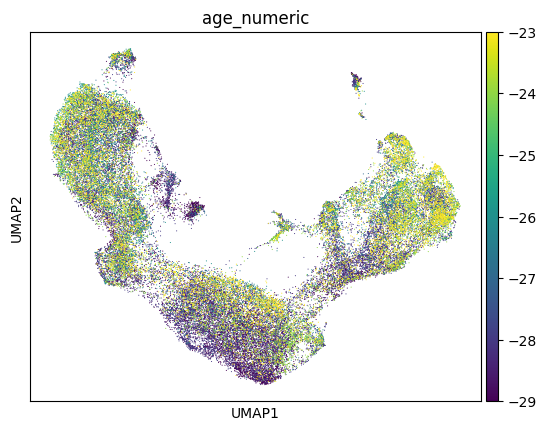

In [21]:
sc.pl.umap(adata, color=['age_numeric'])

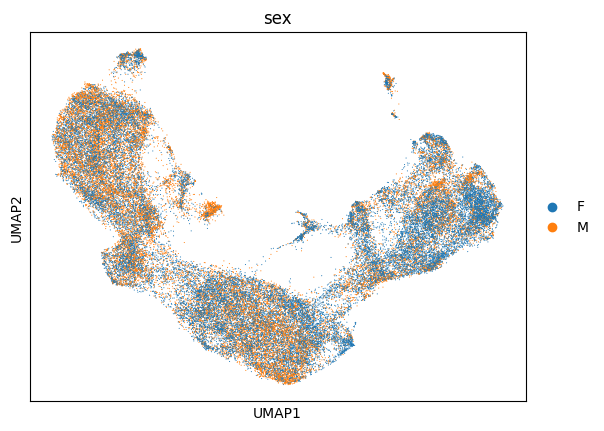

In [17]:
sc.pl.umap(adata, color=['sex'])

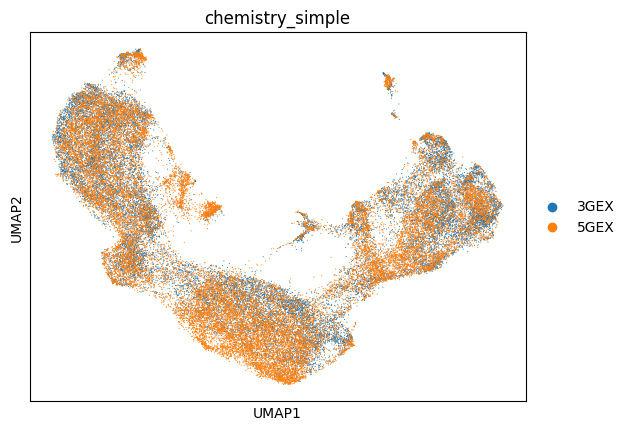

In [18]:
sc.pl.umap(adata, color=['chemistry_simple'])

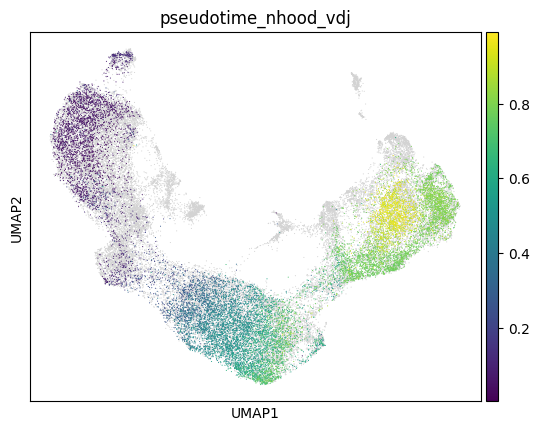

In [19]:
sc.pl.umap(adata, color='pseudotime_nhood_vdj')

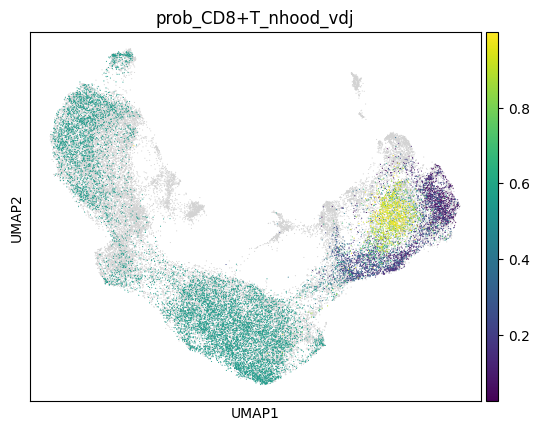

In [20]:
sc.pl.umap(adata, color='prob_CD8+T_nhood_vdj')

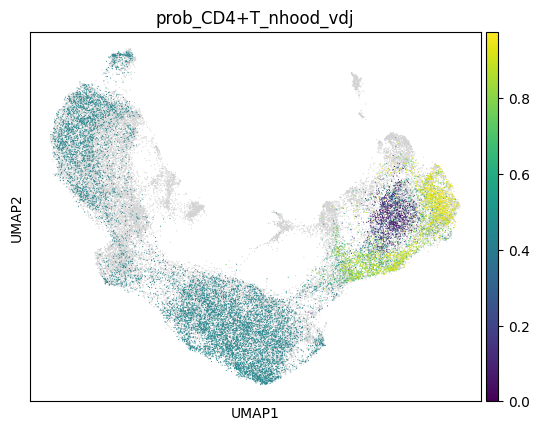

In [22]:
sc.pl.umap(adata, color='prob_CD4+T_nhood_vdj')

In [23]:
adata.write_h5ad(work_dir + 'adata_foetal_T_cells.h5ad')

In [3]:
adata = sc.read_h5ad(work_dir + 'adata_foetal_T_cells.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 50816 × 36601
    obs: 'n_genes', 'sample_barcode', 'batch', 'chemistry_simple', 'age_group', 'age_numeric', 'sampleID_TCRab', 'path_TCRab', 'path_cellbender_gex', 'study', 'study_group', 'sample', 'enrichment', 'donor', 'cite', 'sex', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'barcode_sequence', 'backup_barcode', 'louvian_05', 'leiden_05', 'leiden_1', 'leiden_2', 'park_2020_cell_type', 'panfetal_2022_cell_type', 'cell_type_level_4', 'cell_type_level_3', 'cell_type_level_2', 'cell_type_level_1', 'cell_type_level_0', 'pseudotime_nhood_vdj', 'prob_CD8+T_nhood_vdj', 'prob_CD4+T_nhood_vdj', 'leiden_3', 'leiden_4', 'unannotated', 'pred_cell_type_level_4', 'pred_cell_type_level_4_uncertainties', 'undefined', 'RNA.weight', 'ADTdsb.weight', 'low_ADT', 'spt_CD4', 'spt_CD8', 'anno_CITE', 'c

In [8]:
adata.obs['age_numeric'].value_counts()

age_numeric
-28    14693
-29    11995
-23     8072
-24     6834
-26     6278
-27     2944
Name: count, dtype: int64

In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/ssd/users/Wergillius/Project/PINN_dynamics/data/adata_foetal_T_cells.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 50816 × 36601
    obs: 'n_genes', 'sample_barcode', 'batch', 'chemistry_simple', 'age_group', 'age_numeric', 'sampleID_TCRab', 'path_TCRab', 'path_cellbender_gex', 'study', 'study_group', 'sample', 'enrichment', 'donor', 'cite', 'sex', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'barcode_sequence', 'backup_barcode', 'louvian_05', 'leiden_05', 'leiden_1', 'leiden_2', 'park_2020_cell_type', 'panfetal_2022_cell_type', 'cell_type_level_4', 'cell_type_level_3', 'cell_type_level_2', 'cell_type_level_1', 'cell_type_level_0', 'pseudotime_nhood_vdj', 'prob_CD8+T_nhood_vdj', 'prob_CD4+T_nhood_vdj', 'leiden_3', 'leiden_4', 'unannotated', 'pred_cell_type_level_4', 'pred_cell_type_level_4_uncertainties', 'undefined', 'RNA.weight', 'ADTdsb.weight', 'low_ADT', 'spt_CD4', 'spt_CD8', 'anno_CITE', 'c

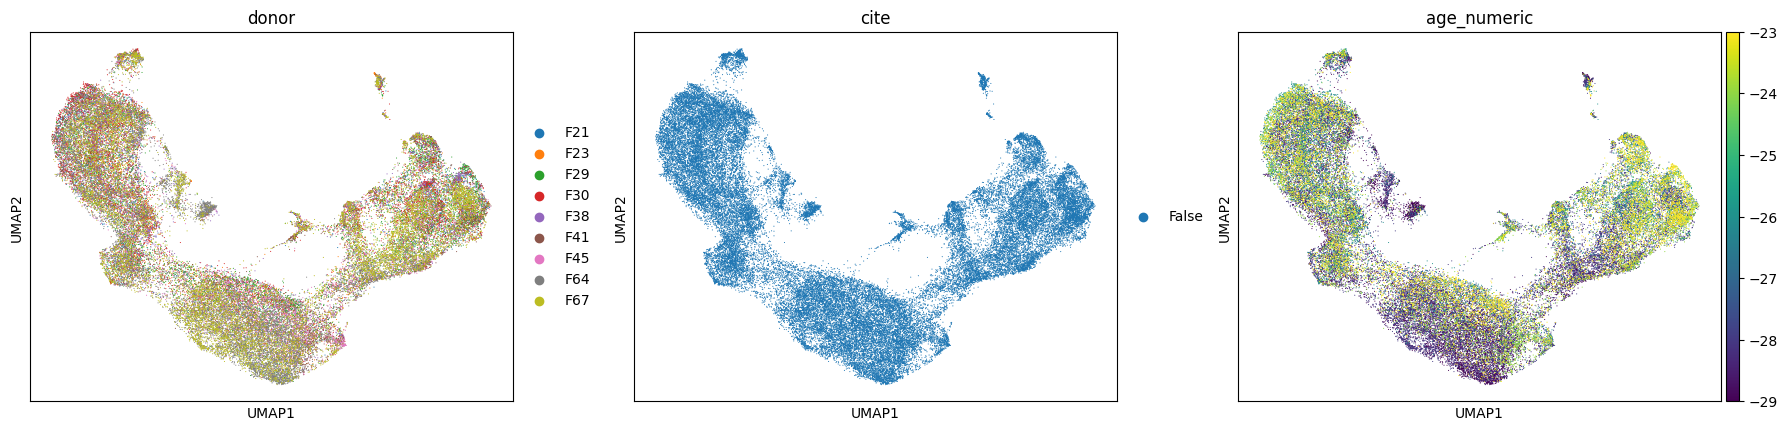

In [5]:
sc.pl.umap(adata, color=['donor', 'cite', 'age_numeric'])

In [10]:
import numpy as np

In [11]:
np.sum(adata.obs['age_numeric'] == -27)

2944